# **Project 42: Stock Price Predictor**

***Pandas*** : *A library for data manipulation and analysis, offering data structures like DataFrames.*

***NumPy*** : *A library for numerical computing in Python, providing support for arrays and mathematical functions.*

***Seaborn*** : *A data visualization library built on Matplotlib, offering enhanced and aesthetically pleasing statistical plots.*

***Matplotlib*** : *A plotting library for creating static, animated, and interactive visualizations in Python.*

***Warnings*** : *A module to control the display of warning messages, allowing filtering or suppression.*

# **LSTM (Long Short-Term Memory):**

*LSTM is a type of RNN designed to overcome the vanishing gradient problem, allowing it to learn long-term dependencies in sequential data. It uses memory cells and gates (input, forget, and output) to control the flow of information and retain information over longer periods. LSTMs are commonly used in tasks like time series forecasting and natural language processing.*

# **RNN (Recurrent Neural Network):**

*RNNs are neural networks designed to handle sequential data by maintaining a hidden state that captures information from previous steps. They have connections that loop back on themselves, allowing them to process sequences of varying lengths. However, they often struggle with long-term dependencies due to issues like vanishing or exploding gradients.*

**Importing these libraries for Data Loading, Data Cleaning and EDA (Eplorotory Data Analysis).**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

**This code disables all warnings from being displayed, allowing the script to run without showing warning messages.**

In [2]:
warnings.simplefilter("ignore")

**This code reads a CSV file named "AAPL.csv" into a Pandas DataFrame and displays the first 5 rows of the DataFrame.**

In [3]:
df = pd.read_csv("/content/AAPL.csv")
df.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-01-03,14.621429,14.732143,14.607143,14.686786,12.402624,302220800
1,2012-01-04,14.642857,14.810000,14.617143,14.765714,12.469276,260022000
2,2012-01-05,14.819643,14.948214,14.738214,14.929643,12.607713,271269600
3,2012-01-06,14.991786,15.098214,14.972143,15.085714,12.739510,318292800
4,2012-01-09,15.196429,15.276786,15.048214,15.061786,12.719307,394024400


**The df.info() method provides a summary of the DataFrame df, including the number of non-null entries, data types of columns, and memory usage.**

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3188 entries, 0 to 3187
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       3188 non-null   str    
 1   Open       3188 non-null   float64
 2   High       3188 non-null   float64
 3   Low        3188 non-null   float64
 4   Close      3188 non-null   float64
 5   Adj Close  3188 non-null   float64
 6   Volume     3188 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 205.6 KB


**The df.isnull().sum() method returns the count of missing (null) values for each column in the DataFrame df.**

In [5]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

# **Prediction Using RNN (Recurrent Neural Networks).**

**These variables "start" and "end" define a time range from the year 2016 to 2020, likely to be used for filtering or analyzing data within this period.**

In [6]:
start = 2016
end = 2020

**This function, train_test_plot, performs the following:**

- **Plot Training Data: Plots the "High" stock prices from the DataFrame df for the years specified by start to end.**

- **Plot Testing Data: Plots the "High" stock prices from the year after end onward.**

**Customize Plot: Adds legends, a title, and displays the combined plot with different colors for training and testing periods.**

In [7]:
def train_test_plot(df, start, end):
    df.loc[f"{start}":f"{end}", "High"].plot(figsize=(16, 4), legend=True)
    df.loc[f"{end+1}":, "High"].plot(figsize=(16, 4), legend=True)
    plt.legend([f"Train (Before {end+1})", f"Test ({end+1} And Beyond)"])
    plt.title("Apple Stock Price")
    plt.show()

**his line of code calls the train_test_plot function, passing the DataFrame df along with the start and end years to generate a plot showing Apple stock prices for the training period (up to end) and testing period (starting from the year after end).**

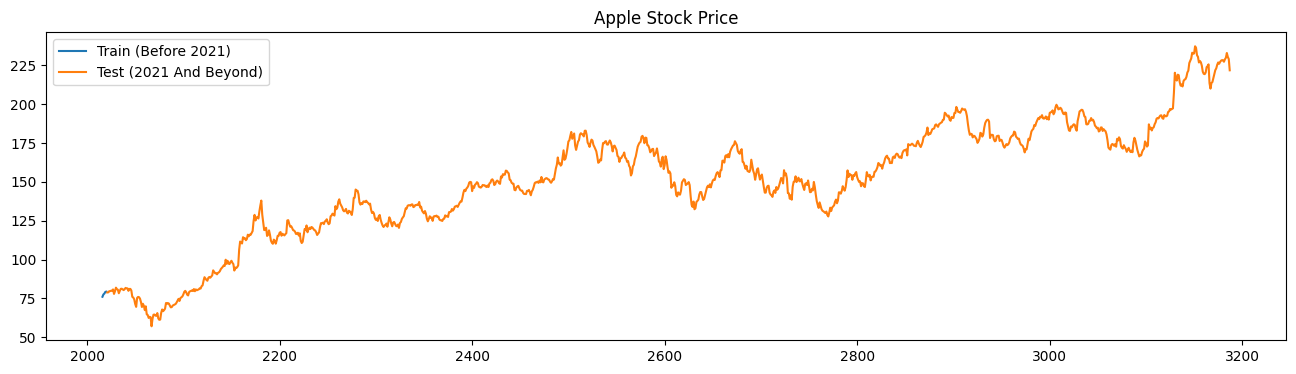

In [8]:
train_test_plot(df, start, end)

**This function, train_test_split, performs the following:**

- **Extract Training Data: Selects values from the specified columns in the DataFrame df from the year start to end and assigns them to train.**

- **Extract Testing Data: Selects values from the specified columns in the DataFrame df starting from the year after end and assigns them to test.**

**Return Data: Returns the train and test arrays.**

In [9]:
def train_test_split(df, start, end, columns = ['High']):
    train = df.loc[f"{start}":f"{end}", columns].values
    test = df.loc[f"{end+1}":, columns].values
    return train, test

**This line of code calls the train_test_split function, passing the DataFrame df, the start year, and the end year to obtain:**

- **training_set: Data values for the period from start to end.**

- **test_set: Data values from the year after end onward.**

In [10]:
training_set, test_set = train_test_split(df, start, end)

**This code snippet performs the following:**

- **Initialize Scaler: Creates a MinMaxScaler instance to scale data within the range [0, 1].**

- **Reshape Data: Reshapes training_set to a 2D array (with one feature column) required by the scaler.**

- **Scale Data: Fits the scaler to training_set and transforms it, scaling the data to the range [0, 1] and assigning it to training_set_scaled.**

In [11]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler(feature_range=(0, 1))
training_set = training_set.reshape(-1, 1)
training_set_scaled = sc.fit_transform(training_set)

**In time series data preparation, n_steps refers to the number of past time steps used to predict the future, and features represents the number of input features per time step.**

In [12]:
n_steps = 1
features = 1

**This function, split_sequence, performs the following:**

- **Initialize Lists: Creates empty lists X and y to store sequences of input features and corresponding labels.**

- **Generate Sequences: Iterates through the input sequence to create sequences of length n_steps (seq_x) and the corresponding next value (seq_y).**

- **Append Sequences: Adds each seq_x and seq_y to X and y respectively.**

- **Return Arrays: Converts X and y to NumPy arrays and returns them.**

In [13]:
def split_sequence(sequence, n_steps):
    X, y = list(), list()
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1:
            break
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

**his line of code applies the split_sequence function to training_set_scaled with the specified n_steps to:**

- **Generate Training Sequences: Create input sequences X_train and corresponding target values y_train from the scaled training data, where each sequence is of length n_steps.**

In [14]:
X_train, y_train = split_sequence(training_set_scaled, n_steps)

**This line of code reshapes X_train to have the shape [number of samples, number of time steps, number of features], where features is set to 1, making X_train suitable for models that require a 3D input shape, such as LSTM networks.**

In [15]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], features)

**This function, plot_predictions, performs the following:**

- **Plot Real Values: Plots the test data in gray, representing the actual values.**

- **Plot Predicted Values: Plots the predicted data in red, representing the model's predictions.**

- **Customize Plot: Adds a title, labels for the x and y axes, a legend, and displays the plot.**

In [16]:
def plot_predictions(test, predicted, title):
    plt.plot(test, color="gray", label="Real")
    plt.plot(predicted, color="red", label="Predicted")
    plt.title(f'{title}')
    plt.xlabel("Time")
    plt.ylabel(f'{title}')
    plt.legend()
    plt.show()

**This function, return_rmse, performs the following:**

- **Calculate RMSE: Computes the Root Mean Squared Error (RMSE) by taking the square root of the mean squared error between test and predicted values.**

- **Print RMSE: Outputs the RMSE value formatted to two decimal places.**

In [17]:
from sklearn.metrics import mean_squared_error

def return_rmse(test, predicted):
    rmse = np.sqrt(mean_squared_error(test, predicted))
    print("The Root Mean Squared Error Is {:.2f}.".format(rmse))

**This function, plot_loss, does the following:**

- **Plot Training Loss: Plots the loss values recorded during training from the history object.**

- **Customize Plot: Sets the figure size, adds a legend, and displays the plot to visualize the training loss over epochs.**

In [18]:
def plot_loss(history):
    plt.figure(figsize=(15, 10))
    plt.plot(history.history["loss"], label="loss")
    plt.legend(loc="best")
    plt.show()

**This code imports essential components for building a Recurrent Neural Network (RNN) using Keras:**

- **Sequential: A linear stack of layers to build the RNN model.**

- **Dense: Fully connected layers used for output and hidden layers in the RNN.**

- **SimpleRNN: Basic RNN layer for processing sequential data.**

- **Dropout: Regularization layer to prevent overfitting by randomly setting a fraction of input units to zero during training.**

In [19]:
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, Dropout

**Sequential Model: Initializes a sequential model for stacking layers.**

**SimpleRNN Layer: Adds an RNN layer with 500 units, expecting input data with shape (n_steps, features).**

**Dense Layer: Adds a fully connected layer with 1 unit for output, suitable for regression tasks.**

In [20]:
model = Sequential()
model.add(SimpleRNN(units=500, input_shape=(n_steps, features)))
model.add(Dense(units=1))

**This code compiles the RNN model with:**

- **optimizer="adam": Uses the Adam optimizer for training, which adapts learning rates during training.**

- **loss="mse": Sets the mean squared error (MSE) as the loss function, commonly used for regression tasks.**

- **model.summary(): Displays the model's architecture, including the layers, their shapes, and the number of parameters.**

In [21]:
model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 500)            │       251,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 251,501 (982.43 KB)

 Trainable params: 251,501 (982.43 KB)

 Non-trainable params: 0 (0.00 B)

**This line of code trains the RNN model using the provided training data:**

- **X_train and y_train: Training features and target values.**

- **epochs=10: Specifies the number of times the model will be trained on the entire dataset.**

- **batch_size=32: Sets the number of samples processed before updating the model's weights.**

- **history: Stores the training process details, including loss metrics over epochs.**

In [22]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.6765
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.5825
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.4959
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.4167
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.3450
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.2808
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.2239
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.1743
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.1318
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0963


**plot_loss(history): Calls the plot_loss function with history (the output from model.fit), which plots the loss values recorded during training to help evaluate the model's performance and convergence.**

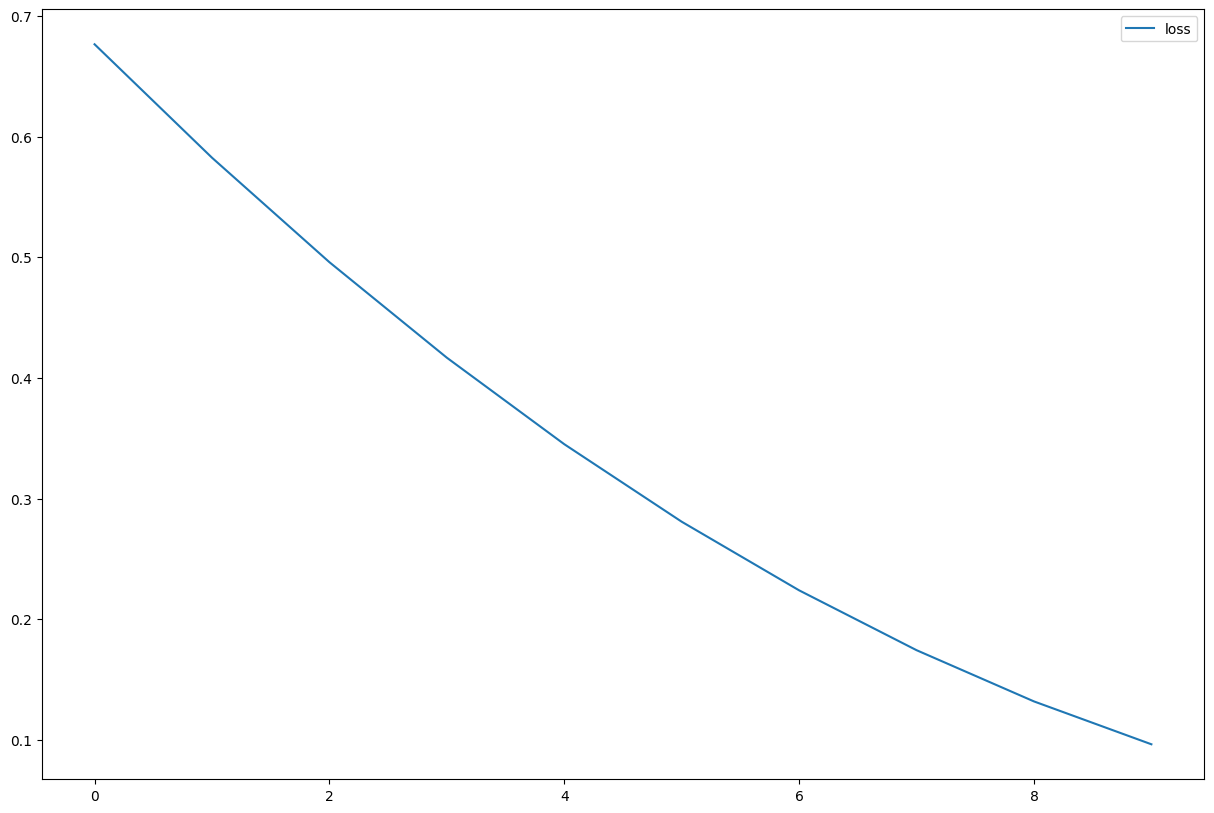

In [23]:
plot_loss(history)

**This line of code preprocesses the test_set data:**

- **test_set.reshape(-1, 1): Reshapes the test_set into a 2D array with one feature column.**

- **sc.transform(...): Scales the reshaped test data using the MinMaxScaler instance sc to ensure it is on the same scale as the training data.**

In [24]:
input = sc.transform(test_set.reshape(-1, 1))

**split_sequence(input, n_steps): Splits the scaled test data into sequences of length n_steps for model input.**

**X_test.reshape(-1, n_steps, features): Reshapes the sequences to match the expected input shape of the model, which is (number_of_samples, n_steps, features).**

In [25]:
X_test, y_test = split_sequence(input, n_steps)
X_test = X_test.reshape(-1, n_steps, features)

**model.predict(X_test): Uses the trained RNN model to predict stock prices based on the test data.**

**sc.inverse_transform(predicted_stock_price): Converts the scaled predictions back to the original stock price values using the inverse transformation of MinMaxScaler.**

In [26]:
predicted_stock_price = model.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


**This line of code visualizes the model's predictions against the actual stock prices.**

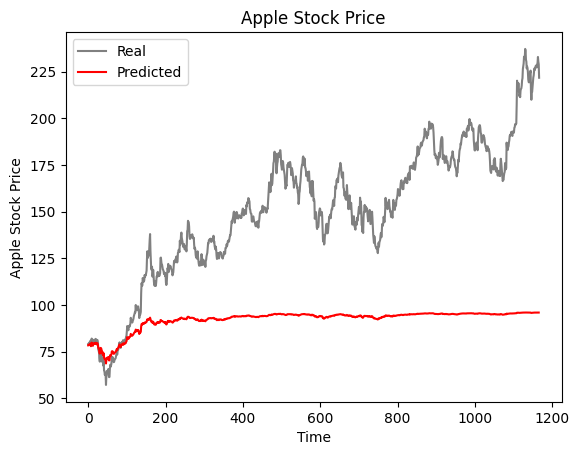

In [27]:
plot_predictions(test_set, predicted_stock_price, "Apple Stock Price")

**steps_in_future = 25: Specifies that the model will forecast the stock prices for the next 25 time steps beyond the available data.**

In [28]:
steps_in_future = 25

**This function generates future stock price predictions:**

- **high_dataset: Extracts and scales the most recent stock prices from the dataset, preparing the initial input for predictions.**

- **inputs: Initializes with the scaled stock prices of the last n_steps time steps.**

- **for _ in range(steps_future): Iteratively predicts future stock prices by feeding the most recent predictions back into the model to generate subsequent forecasts.**

- **sc.inverse_transform(inputs[n_steps:]): Converts the scaled future predictions back to the original stock price values.**

In [29]:
def sequence_generation(dataset: pd.DataFrame, sc: MinMaxScaler, model:Sequential, steps_future: int):
    high_dataset = dataset.iloc[len(dataset) - len(test_set) - n_steps:]["High"]
    high_dataset = sc.transform(high_dataset.values.reshape(-1, 1))
    inputs = high_dataset[:n_steps]

    for _ in range(steps_future):
        curr_pred = model.predict(inputs[-n_steps:].reshape(-1, n_steps, features), verbose=0)
        inputs = np.append(inputs, curr_pred, axis=0)

    return sc.inverse_transform(inputs[n_steps:])

**This line of code generates future stock price predictions:**

- **results = sequence_generation(df, sc, model, steps_in_future): Calls the sequence_generation function to predict stock prices for the next steps_in_future time steps, using the provided DataFrame df, the MinMaxScaler sc, and the trained model. The predictions are stored in results.**

In [30]:
results = sequence_generation(df, sc, model, steps_in_future)

**This line visualizes the predicted future stock prices compared to the actual future values:**

- **plot_predictions(test_set[:steps_in_future], results, "Apple Stock Price"): Uses the plot_predictions function to plot the actual stock prices (test_set[:steps_in_future]) and the predicted future stock prices (results) on the same graph, with the title "Apple Stock Price". This helps in assessing the model's performance in forecasting future stock prices.**

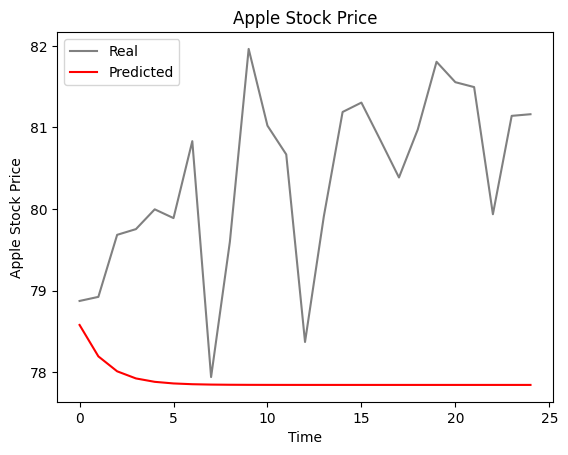

In [31]:
plot_predictions(test_set[:steps_in_future], results, "Apple Stock Price")

# **Prediction Using LSTM (Long Short Term Memory).**

* **"LSTM(2000, input_shape=(n_steps, features), return_sequences=False)" adds a recurrent layer that learns temporal patterns from sequential data and outputs only the final time step representation.**

* **"Dense(units=1)" adds a fully connected layer that maps the learned sequence representation to a single numeric output.**

* **"Dropout(0.3)" randomly disables 30% of neurons during training to reduce overfitting, and "Dense(1, activation='linear')" produces a continuous-valued prediction for regression tasks.**


In [32]:
from keras.layers import LSTM

model = Sequential()
model.add(LSTM(2000, input_shape=(n_steps, features), return_sequences=False))
model.add(Dense(units=1))

model.add(Dropout(0.3))
model.add(Dense(1, activation='linear'))

* **optimizer="adam" selects an adaptive optimization algorithm that adjusts learning rates automatically during training for faster convergence.**

* **loss="mse" defines Mean Squared Error as the objective function used to train the model by penalizing larger prediction errors more heavily.**

* **metrics=["mse"] tracks Mean Squared Error during training and model.summary() prints the model architecture, layer shapes, and total parameters.**

In [33]:
model.compile(optimizer="adam", loss="mse", metrics=["mse"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 2000)           │    16,016,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         2,001 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,018,003 (61.10 MB)

 Trainable params: 16,018,003 (61.10 MB)

 Non-trainable params: 0 (0.00 B)

* **"model.fit(X_train, y_train, ...)" starts training the neural network by feeding input data and target values into the model.**

* **"epochs=50" means the model will iterate over the entire training dataset 50 times to progressively minimize the loss.**

* **"batch_size=64" controls how many samples are processed before updating model weights, balancing training speed and stability.**

In [34]:
history = model.fit(X_train, y_train, epochs=50, batch_size = 64)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.6281 - mse: 0.6281
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - loss: 0.5556 - mse: 0.5556
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step - loss: 0.4888 - mse: 0.4888
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - loss: 0.3840 - mse: 0.3840
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step - loss: 0.5707 - mse: 0.5707
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step - loss: 0.2883 - mse: 0.2883
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step - loss: 0.3786 - mse: 0.3786
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step - loss: 0.1980 - mse: 0.1980
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step - loss: 0.3737 - mse: 0.3737
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step - loss: 0.1748 - mse: 0.1748
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - loss: 0.2857 - mse: 0.2857
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step - loss: 0.0823 - mse: 0.0823
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step -

**The plot_loss(history) function will visualize the training loss over epochs:**

- **history: Contains the loss values recorded during training.**

- **plot_loss(history): Plots the training loss to show how it changed over each epoch.**

- **This helps to assess the model's convergence and performance during training.**

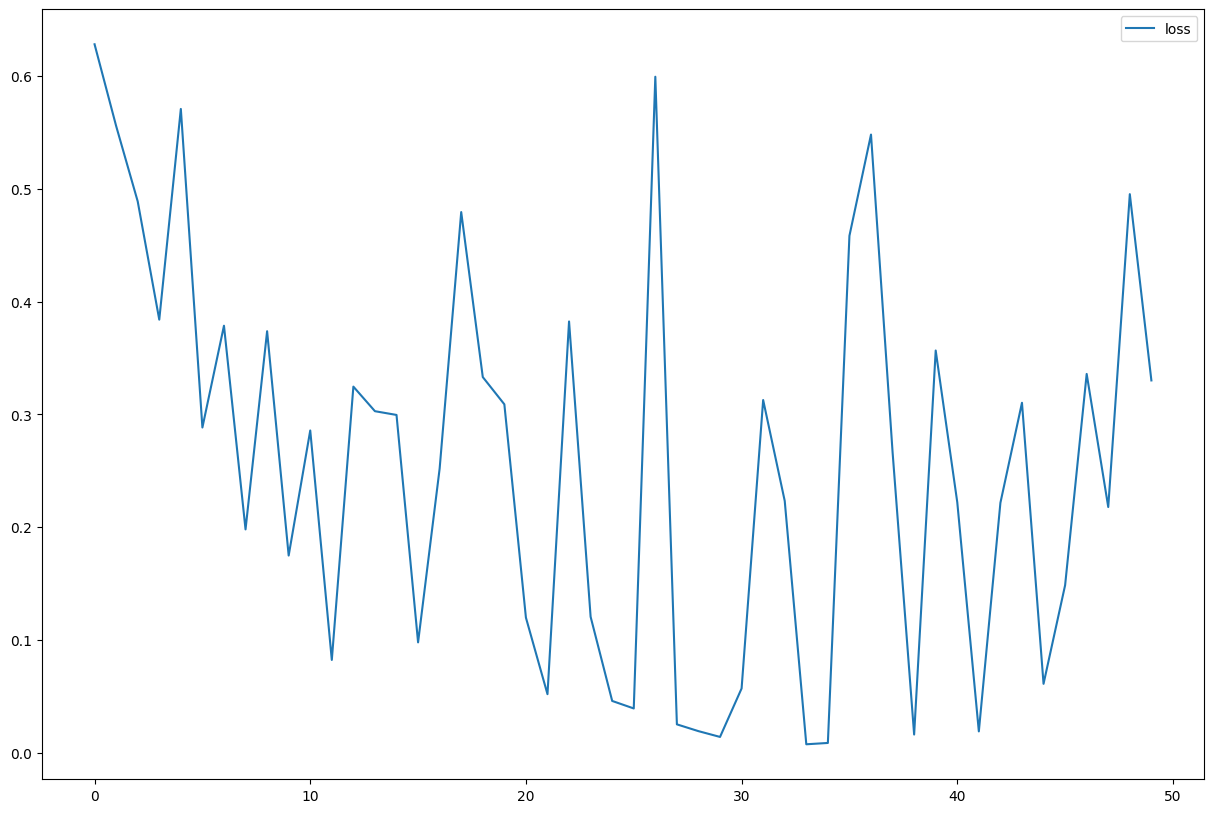

In [35]:
plot_loss(history)

**The code predicts stock prices using a trained LSTM model and then scales these predictions back to their original values with MinMaxScaler. This allows for a direct comparison of the predicted prices to the actual values.**

In [36]:
predicted_stock_price = model.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step


**This will display a plot comparing the actual stock prices (test_set) with the predicted prices (predicted_stock_price) generated by the LSTM model.**

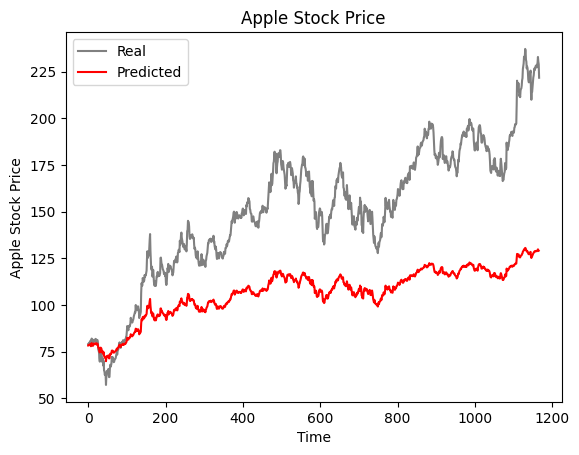

In [37]:
plot_predictions(test_set, predicted_stock_price, "Apple Stock Price")

**The sequence_generation function generates future stock price predictions based on the LSTM model. The results contain the predicted stock prices for the specified number of future steps.**

In [38]:
results = sequence_generation(df, sc, model, steps_in_future)

**This will show a plot with the actual stock prices for the initial future steps and the predicted prices generated by the model.**

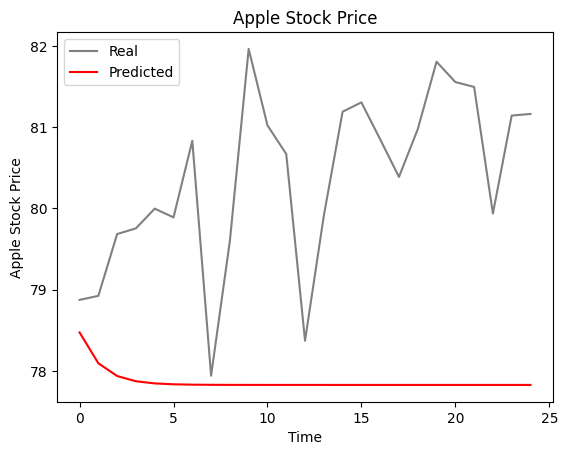

In [39]:
plot_predictions(test_set[:steps_in_future], results, "Apple Stock Price")

# **Time Series Prediction**

**The code creates a copy of the DataFrame df and assigns it to multi_variate_df while setting mv_features to 6, indicating the number of features in the multivariate dataset. This prepares multi_variate_df for processing with six features.**

In [40]:
mv_features = 6
multi_variate_df = df.copy()

**The command !pip install pandas_ta installs the pandas_ta library, which is an extension for technical analysis with pandas DataFrames, providing various technical indicators for financial data analysis.**

In [41]:
!pip install pandas_ta

**This code calculates and adds four technical indicators to the multi_variate_df DataFrame:**

- **RSI: Relative Strength Index with a 15-day period, added as 'RSI'.**

- **EMAF: Exponential Moving Average with a 20-day period, added as 'EMAF'.**

- **EMAM: Exponential Moving Average with a 100-day period, added as 'EMAM'.**

- **EMAS: Exponential Moving Average with a 150-day period, added as 'EMAS'.**

In [42]:
import pandas_ta as ta

multi_variate_df['RSI'] = ta.rsi(multi_variate_df.Close, length=15)
multi_variate_df['EMAF'] = ta.ema(multi_variate_df.Close, length=20)
multi_variate_df['EMAM'] = ta.ema(multi_variate_df.Close, length=100)
multi_variate_df['EMAS'] = ta.ema(multi_variate_df.Close, length=150)

**This code creates a target variable for prediction by computing the difference between the adjusted closing price ('Adj Close') and the opening price ('Open'), shifts it by one day to use future information, and then cleans the DataFrame by removing rows with missing values and dropping the 'Volume' and 'Close' columns.**

In [43]:
multi_variate_df['Target'] = multi_variate_df['Adj Close'] - df.Open
multi_variate_df['Target'] = multi_variate_df['Target'].shift(-1)
multi_variate_df.dropna(inplace=True)
multi_variate_df.drop(['Volume', 'Close'], axis=1, inplace=True)

**This code plots the 'High' price and the 'RSI' (Relative Strength Index) values for Apple stock within the specified date range, providing a visual comparison of stock price and RSI trends.**

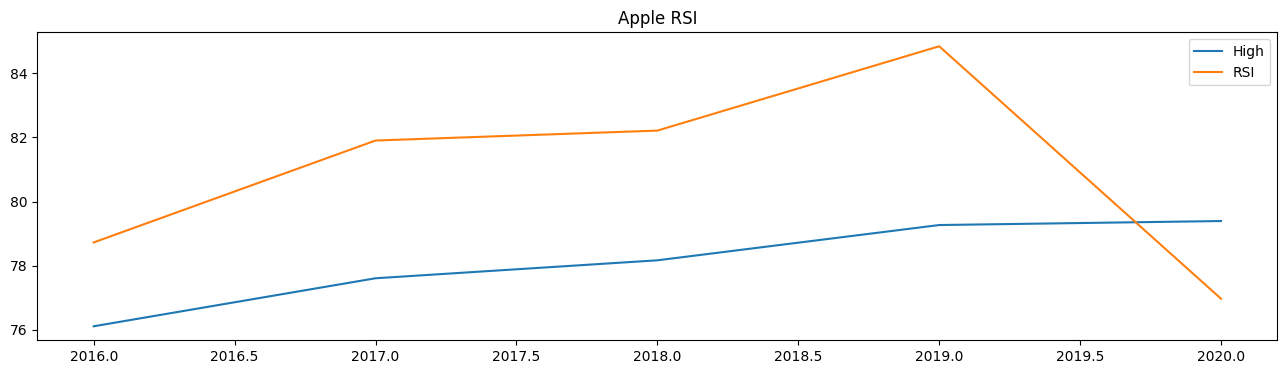

In [44]:
multi_variate_df.loc[f"{start}":f"{end}", ["High", "RSI"]].plot(figsize=(16, 4), legend=True)
plt.title("Apple RSI")
plt.show()

**This code plots the 'High' price along with three different exponential moving averages ('EMAF', 'EMAM', 'EMAS') for Apple stock over the specified date range, showing the stock price and its smoothed trends.**

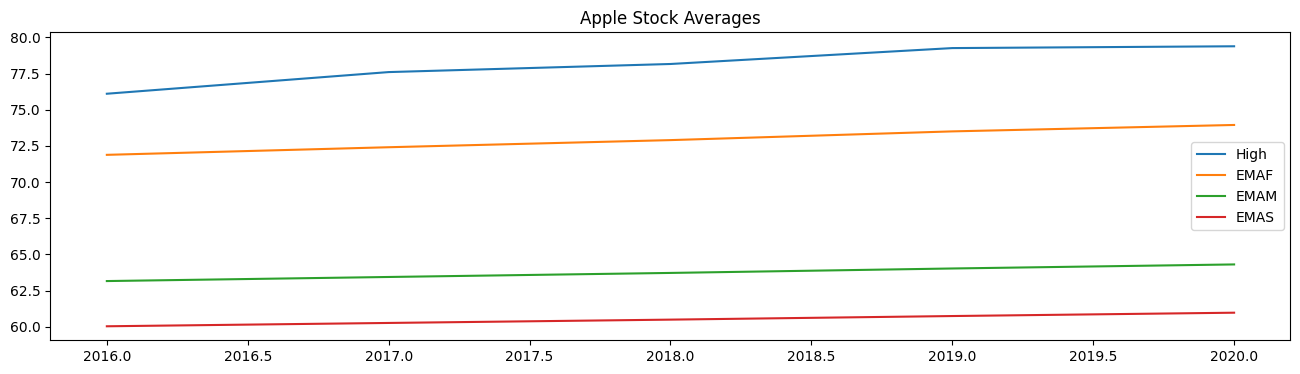

In [45]:
multi_variate_df.loc[f"{start}":f"{end}", ['High', 'EMAF', 'EMAM', 'EMAS']].plot(figsize=(16, 4), legend=True)
plt.title("Apple Stock Averages")
plt.show()

**Feature columns and label column for your multivariate time series analysis.**

In [46]:
feat_columns = ['Open', 'High', 'RSI', 'EMAF', 'EMAM', 'EMAS']
label_col = ['Target']

**The code splits the multi_variate_df DataFrame into training and test sets based on the specified start and end dates. It uses the feature columns (feat_columns) and label column (label_col) to create these subsets**:

- **mv_training_set contains data from start to end for training.**

- **mv_test_set contains data from end+1 onwards for testing.**

- **You can now preprocess and use these sets for your model.**

In [47]:
mv_training_set, mv_test_set = train_test_split(multi_variate_df, start, end, feat_columns + label_col)

**The code is slicing the mv_training_set and mv_test_set arrays to separate features and labels:**

- **X_train and X_test are arrays of feature columns, excluding the last column (the target variable).**

- **y_train and y_test are arrays of the target variable (last column).**

In [48]:
X_train = mv_training_set[:, :-1]
y_train = mv_training_set[:, -1]

X_test = mv_test_set[:, :-1]
y_test = mv_test_set[:, -1]

**The code normalizes feature data for multivariate time series:**

- **X_train is scaled to the range [0, 1] and reshaped to 3D for LSTM input (samples, time steps, features).**

- **X_test is scaled similarly and reshaped to match the input shape for the LSTM model.**

In [49]:
mv_sc = MinMaxScaler(feature_range=(0, 1))
X_train = mv_sc.fit_transform(X_train).reshape(-1, 1, mv_features)
X_test = mv_sc.transform(X_test).reshape(-1, 1, mv_features)

**The code sets up an LSTM model for multivariate time series forecasting:**

- **Model Structure: An LSTM layer with 125 units followed by a Dense layer with 1 unit.**

- **Compilation: The model is compiled with the RMSprop optimizer and mean squared error (MSE) loss function.**

In [50]:
model_mv = Sequential()
model_mv.add(LSTM(units=125, input_shape=(1, mv_features)))
model_mv.add(Dense(units=1))
model_mv.compile(optimizer="RMSprop", loss="mse")

**The code trains the LSTM model on the multivariate time series data for 20 epochs with a batch size of 32, and then plots the training loss to visualize the model's performance over epochs.**

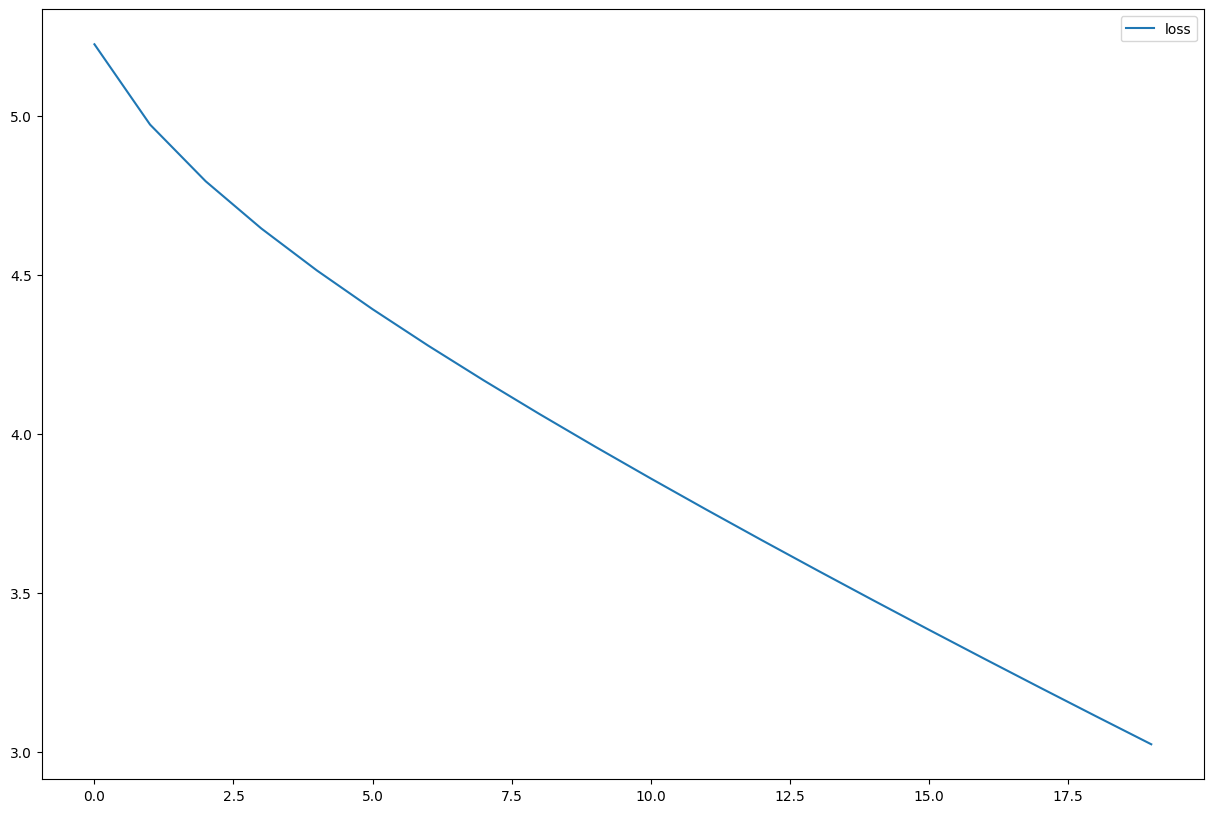

In [51]:
history = model_mv.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)
plot_loss(history)

**The code generates predictions using the trained LSTM model on the test set and plots these predictions against the actual test data to compare their performance visually.**

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


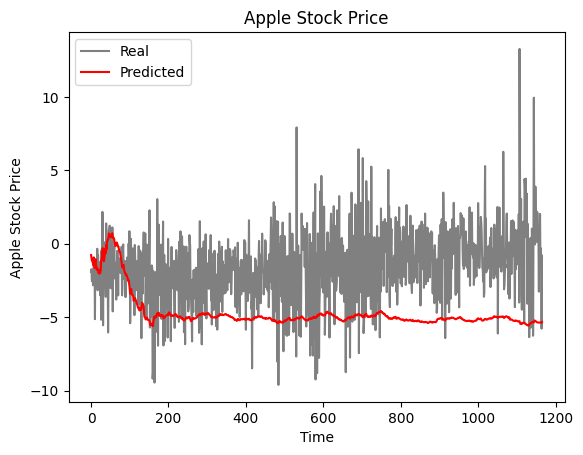

In [52]:
predictions = model_mv.predict(X_test)
plot_predictions(y_test, predictions, "Apple Stock Price")